# Information asymétrique : antisélection et marché des lemons

Ce notebook étudie l’**antisélection**, c’est-à-dire l’information privée détenue avant l’échange ou la signature d’un contrat. Il prépare deux extensions distinctes : le **signaling**, où l’agent informé choisit un signal coûteux, et le **screening**, où le côté non informé propose un dispositif d’auto-sélection. L’aléa moral, qui concerne une action privée après contrat, reste hors du modèle principal.

Le cadre commun est celui de Harsanyi : un type privé est tiré selon un prior commun, puis la stratégie de l’agent informé peut dépendre de ce type. Cette première tranche implémente le modèle price-only d’Akerlof ; elle n’y ajoute ni menu, ni signal, ni condition de single-crossing.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
print("Environnement prêt : NumPy, pandas et Matplotlib chargés")

Environnement prêt : NumPy, pandas et Matplotlib chargés


## Akerlof : un point fixe de participation à prix unique

Le vendeur observe la qualité $q\in\{L,H\}$. À un prix candidat $P$, les vendeurs participants forment

$$S(P)=\{q\mid c_q\le P\}.$$

Lorsque cet ensemble est non vide, l’acheteur accepte si

$$P\le \mathbb E[v(q)\mid q\in S(P)].$$

Le prix doit donc être compatible simultanément avec la participation des vendeurs et la disposition à payer de l’acheteur. Pour faire participer les deux qualités, il faut $P\ge c_H$ et $P\le \pi v_H+(1-\pi)v_L$. Si $v_H>v_L$, le pooling devient donc possible lorsque

$$\pi\ge\pi_{min}=\frac{c_H-v_L}{v_H-v_L}.$$

Ce seuil vaut uniquement pour le modèle fini défini ici.

In [2]:
def akerlof_equilibria(
    pi: float,
    c_low: float,
    c_high: float,
    v_low: float,
    v_high: float,
) -> list[dict[str, object]]:
    """Énumère tous les intervalles de prix compatibles avec le point fixe."""
    if not 0.0 <= pi <= 1.0:
        raise ValueError("pi doit appartenir à [0, 1]")
    if not c_low < c_high:
        raise ValueError("Le modèle suppose c_low < c_high")
    if not v_low < v_high:
        raise ValueError("Le modèle suppose v_low < v_high")

    equilibria: list[dict[str, object]] = []

    # Dans cet intervalle, seul L participe. La borne c_high est ouverte,
    # car le vendeur H entre exactement lorsque P = c_high.
    lemons_upper = min(c_high, v_low)
    if c_low <= lemons_upper:
        equilibria.append({
            "regime": "lemons_only",
            "participants": ("L",),
            "price_lower": c_low,
            "price_upper": lemons_upper,
            "upper_closed": v_low < c_high,
            "conditional_value": v_low,
        })

    # Lorsque les deux qualités participent, l’espérance conditionnelle
    # coïncide avec la valeur pondérée par le prior.
    pooling_value = pi * v_high + (1.0 - pi) * v_low
    if c_high <= pooling_value:
        equilibria.append({
            "regime": "pooling",
            "participants": ("L", "H"),
            "price_lower": c_high,
            "price_upper": pooling_value,
            "upper_closed": True,
            "conditional_value": pooling_value,
        })

    if not equilibria:
        return [{"regime": "no_trade", "participants": ()}]
    return equilibria


print("Modèle prêt : trois régimes possibles (lemons-only, pooling, no-trade)")

Modèle prêt : trois régimes possibles (lemons-only, pooling, no-trade)


In [3]:
scenarios = [
    {"scenario": "faible part de H", "pi": 0.20, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "seuil exact", "pi": 1 / 3, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "forte part de H", "pi": 0.50, "c_low": 1, "c_high": 5, "v_low": 3, "v_high": 9},
    {"scenario": "aucun échange", "pi": 0.50, "c_low": 4, "c_high": 7, "v_low": 3, "v_high": 6},
]

rows = []
for scenario in scenarios:
    parameters = {key: value for key, value in scenario.items() if key != "scenario"}
    for equilibrium in akerlof_equilibria(**parameters):
        rows.append({"scenario": scenario["scenario"], "pi": scenario["pi"], **equilibrium})

akerlof_results = pd.DataFrame(rows)
akerlof_results


,scenario,pi,regime,participants,price_lower,price_upper,upper_closed,conditional_value
0,faible part de H,0.200000,lemons_only,"(L,)",1.0,3.0,True,3.0
1,seuil exact,0.333333,lemons_only,"(L,)",1.0,3.0,True,3.0
2,seuil exact,0.333333,pooling,"(L, H)",5.0,5.0,True,5.0
3,forte part de H,0.500000,lemons_only,"(L,)",1.0,3.0,True,3.0
4,forte part de H,0.500000,pooling,"(L, H)",5.0,6.0,True,6.0
5,aucun échange,0.500000,no_trade,(),NaN,NaN,NaN,NaN


### Lecture du résultat

Au-dessus du seuil $\pi_{min}=(c_H-v_L)/(v_H-v_L)=1/3$, un intervalle pooling devient compatible. Il ne fait pas disparaître automatiquement l’intervalle lemons-only : plusieurs équilibres peuvent coexister. Au seuil exact, le pooling est un singleton $P=c_H$. Cette multiplicité est un résultat du point fixe, pas une erreur de classification.

## Exercice 1 — classer les régimes

À partir du tableau précédent, compléter la fonction pour associer à chaque scénario l’ensemble de ses régimes. Vérifier en particulier que le scénario au seuil admet deux régimes, tandis que le dernier conduit à `no_trade`.

**Indice :** grouper les lignes par `scenario`, puis convertir la colonne `regime` en ensemble.

In [4]:
def exercice_classer_regimes() -> dict[str, set[str]] | None:
    # TODO étudiant : grouper akerlof_results par scénario et collecter les régimes.
    return None


print("Classification à compléter :", exercice_classer_regimes())

Classification à compléter : None


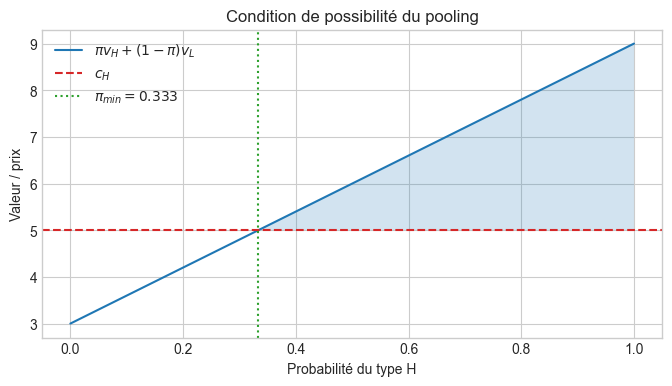

In [5]:
pi_values = np.linspace(0, 1, 201)
pooling_values = pi_values * 9 + (1 - pi_values) * 3
pi_min = (5 - 3) / (9 - 3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pi_values, pooling_values, label=r"$\pi v_H+(1-\pi)v_L$")
ax.axhline(5, color="tab:red", linestyle="--", label=r"$c_H$")
ax.axvline(pi_min, color="tab:green", linestyle=":", label=fr"$\pi_{{min}}={pi_min:.3f}$")
ax.fill_between(pi_values, 5, pooling_values, where=pooling_values >= 5, alpha=0.2)
ax.set(
    xlabel="Probabilité du type H",
    ylabel="Valeur / prix",
    title="Condition de possibilité du pooling",
)
ax.legend()
plt.show()


## Exercice 2 — retrouver le seuil graphiquement

Compléter la fonction pour retourner le premier prior de la grille `pi_values` tel que la valeur du pooling atteint `c_high = 5`. Comparer ce résultat numérique à la formule analytique de $\pi_{min}$.

**Indice :** utiliser un masque booléen sur `pooling_values`, puis sélectionner son premier indice vrai.

In [6]:
def exercice_seuil_numerique() -> float | None:
    # TODO étudiant : trouver le premier pi tel que pooling_values >= 5.
    return None


print("Seuil numérique à compléter :", exercice_seuil_numerique())

Seuil numérique à compléter : None


## Exercice 3 — frontière d’Akerlof

Compléter la fonction suivante pour détecter si l’intervalle pooling se réduit à un prix unique au seuil $\pi_{min}$. Vérifier ensuite que `lemons_only` et `pooling` peuvent tous deux apparaître dans la liste retournée.

**Étape 1 :** appeler `akerlof_equilibria` au seuil.  
**Étape 2 :** isoler le régime `pooling`.  
**Étape 3 :** comparer ses bornes inférieure et supérieure.

In [7]:
def exercice_pooling_singleton() -> bool | None:
    # TODO étudiant : appeler akerlof_equilibria au seuil et comparer les bornes.
    return None


print("Résultat à compléter :", exercice_pooling_singleton())


Résultat à compléter : None


## Prolongements prévus

Les tranches suivantes ajouteront :

- Spence : utilité $w-c$, contraintes IC/IR et séparateur de Riley ;
- Rothschild–Stiglitz : Nash entre assureurs et déviations cream-skimming ;
- Wilson/Miyazaki/Spence : menus finis avec une règle de retrait anticipée explicitement codée ;
- un lien formel vers les jeux bayésiens finis existants.

Aucun résultat général d’existence ou d’unicité n’est supposé avant que ses hypothèses soient définies.